# Figure 3
## Width selection for lncRNA analyses
### Author: Martin Loza
### Date: 25/12/09

After selecting relationships related to lncRNA, we need to select the window size for downstream analyses.
We would like to generate plots that allows us to define thresholds for downstream analyses

In [1]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "251209"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_3/Plots/"

# Local Functions

# Simplified function to calculate density metrics for a given window size
calculate_density_metrics <- function(data, window_size, distance_column = "abs_strand_distance") {
    # Filter data within the window
    filtered_data <- data %>%
        filter(!!sym(distance_column) <= window_size)
    
    # Calculate counts and density
    metrics <- filtered_data %>%
        group_by(ncrna_strand) %>%
        summarise(count = n(), .groups = 'drop') %>%
        mutate(
            window_size = window_size,
            strand = ifelse(ncrna_strand == 1, "Forward", "Reverse"),
            density = count / window_size
        )
    
    return(metrics)
}

### Load and setup the data

In [2]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["human"]], 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE


In [5]:
# Let's place an order in the plots
ordered_species <- c("human", "mouse")
# Arrange the data_list according to the ordered_species
data_selected_list <- data_list[ordered_species]

Let's also focus only in standard chromosomes

In [6]:
unique(data_selected_list[["mouse"]]$chromosome)

[1] "6"  "2"  "10" "11" "12" "13" "14" "15" "18" "1"  "3"  "5"  "7"  "X"  "8" 
[16] "9"  "16" "17" "4"  "19" "Y"

In [7]:
# remove data_list to avoid confusion
rm(data_list)

Let's focus only in lncRNAs

In [13]:
# Select only observations related to lncRNA
for (species in names(data_selected_list)) {
    data_selected_list[[species]] <- data_selected_list[[species]] %>%
        filter(gene_biotype == "lncRNA")
}

In [16]:
head(data_selected_list[["human"]], 3)
table(data_selected_list[["human"]]$gene_biotype)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,abs_strand_distance
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<int>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE,749281
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE,931960
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE,539913



 lncRNA 
4155667 

In this case, we will focus only on PCGs annotated as TF

In [17]:
cat("Number of human PCGs:", length(unique(data_selected_list[["human"]]$pcg_gene_name)), "\n")
cat("Number of human TF-PCGs :", data_selected_list[["human"]] %>% filter(is_TF) %>% pull(pcg_gene_name) %>% unique() %>% length(), "\n")

cat("Number of mouse PCGs:", length(unique(data_selected_list[["mouse"]]$pcg_gene_name)), "\n")
cat("Number of mouse TF-PCGs :", data_selected_list[["mouse"]] %>% filter(is_TF) %>% pull(pcg_gene_name) %>% unique() %>% length(), "\n")

Number of human PCGs: 19342 
Number of human TF-PCGs : 1629 
Number of mouse PCGs: 21471 
Number of mouse TF-PCGs : 1563 


### Selection of the thresholds

Let's try to analyse the density of PCG around ncRNA's TSS with different width thresholds.

In this case, let's get and absolute distance to avoid any effects from upstream and downstream location

In [18]:
# Add absolute distance column
for (species in names(data_selected_list)) {
    data_selected_list[[species]] <- data_selected_list[[species]] %>%
        mutate(abs_strand_distance = abs(strand_distance))
}

In [19]:
# Define the window sizes to compare (in bp)
window_sizes <- c(1000, 5000, 10000, 50000, 100000, 500000, 1000000)

In [20]:
# Separate data into TF and non-TF sets
data_TF_list <- list()
data_nonTF_list <- list()

for (species in names(data_selected_list)) {
    data_TF_list[[species]] <- data_selected_list[[species]] %>% filter(is_TF)
    data_nonTF_list[[species]] <- data_selected_list[[species]] %>% filter(!is_TF)
}

# Calculate density metrics for TF genes
all_density_TF <- list()

for (species in names(data_TF_list)) {
    species_metrics <- data.frame()
    
    for (ws in window_sizes) {
        temp_metrics <- calculate_density_metrics(data_TF_list[[species]], window_size = ws)
        species_metrics <- rbind(species_metrics, temp_metrics)
    }
    
    species_metrics$species <- species
    species_metrics$gene_type <- "TF"
    all_density_TF[[species]] <- species_metrics
}

# Calculate density metrics for non-TF genes
all_density_nonTF <- list()

for (species in names(data_nonTF_list)) {
    species_metrics <- data.frame()
    
    for (ws in window_sizes) {
        temp_metrics <- calculate_density_metrics(data_nonTF_list[[species]], window_size = ws)
        species_metrics <- rbind(species_metrics, temp_metrics)
    }
    
    species_metrics$species <- species
    species_metrics$gene_type <- "non-TF"
    all_density_nonTF[[species]] <- species_metrics
}

# Combine TF and non-TF metrics
density_TF_df <- do.call(rbind, all_density_TF)
density_nonTF_df <- do.call(rbind, all_density_nonTF)
density_df <- rbind(density_TF_df, density_nonTF_df)
rownames(density_df) <- NULL

head(density_df, 3)

ncrna_strand,count,window_size,strand,density,species,gene_type
<int>,<int>,<dbl>,<chr>,<dbl>,<chr>,<chr>
-1,17738,1000,Reverse,17.7380,human,TF
1,19990,1000,Forward,19.9900,human,TF
-1,22759,5000,Reverse,4.5518,human,TF


### Main Figure: TF vs non-TF density comparison

In [21]:
# Aggregate density across strands for simplified comparison
density_combined_df <- density_df %>%
    group_by(species, window_size, gene_type) %>%
    summarise(
        total_count = sum(count),
        combined_density = total_count / window_size,
        .groups = 'drop'
    )

# Remove duplicated rows if any
density_combined_df <- density_combined_df %>% distinct()

head(density_combined_df)

Warning message:
“Returning more (or less) than 1 row per `summarise()` group was deprecated in
dplyr 1.1.0.
ℹ Please use `reframe()` instead.
ℹ When switching from `summarise()` to `reframe()`, remember that `reframe()`
  always returns an ungrouped data frame and adjust accordingly.”


species,window_size,gene_type,total_count,combined_density
<chr>,<dbl>,<chr>,<int>,<dbl>
human,1000,TF,37728,37.7280
human,1000,non-TF,29952,29.9520
human,5000,TF,47508,9.5016
human,5000,non-TF,39170,7.8340
human,10000,TF,55454,5.5454
human,10000,non-TF,50125,5.0125


In [22]:
# Perform statistical testing for TF vs non-TF at each window size
# Using Wilcoxon test on the raw counts
pvalue_results <- list()

for (sp in unique(density_combined_df$species)) {
    for (ws in window_sizes) {
        # Get the raw data for this species and window
        tf_data <- data_TF_list[[sp]] %>% 
            filter(abs_strand_distance <= ws)
        nontf_data <- data_nonTF_list[[sp]] %>% 
            filter(abs_strand_distance <= ws)
        
        # Get counts
        tf_count <- nrow(tf_data)
        nontf_count <- nrow(nontf_data)
        
        # Calculate densities
        tf_density <- tf_count / ws
        nontf_density <- nontf_count / ws
        
        # Perform proportion test (comparing if TF proportion is different from non-TF)
        # Using chi-square or Fisher's exact test for count data
        total_genes_tf <- nrow(data_TF_list[[sp]])
        total_genes_nontf <- nrow(data_nonTF_list[[sp]])
        
        # Create contingency table: [in_window, not_in_window] x [TF, non-TF]
        cont_table <- matrix(c(tf_count, total_genes_tf - tf_count,
                               nontf_count, total_genes_nontf - nontf_count),
                             nrow = 2, byrow = FALSE)
        
        test_result <- chisq.test(cont_table)
        
        pvalue_results[[length(pvalue_results) + 1]] <- data.frame(
            species = sp,
            window_size = ws,
            pvalue = test_result$p.value,
            tf_density = tf_density,
            nontf_density = nontf_density
        )
    }
}

pvalue_df <- do.call(rbind, pvalue_results)

# Apply FDR correction (Benjamini-Hochberg)
pvalue_df <- pvalue_df %>%
    mutate(
        fdr = p.adjust(pvalue, method = "fdr"),
        significance = case_when(
            fdr < 0.001 ~ "***",
            fdr < 0.01 ~ "**",
            fdr < 0.05 ~ "*",
            TRUE ~ ""
        )
    )

print(pvalue_df)

Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”
Warning message in chisq.test(cont_table):
“Chi-squared approximation may be incorrect”


   species window_size        pvalue tf_density nontf_density           fdr
1    human       1e+03  0.000000e+00  37.728000     29.952000  0.000000e+00
2    human       5e+03  0.000000e+00   9.501600      7.834000  0.000000e+00
3    human       1e+04  0.000000e+00   5.545400      5.012500  0.000000e+00
4    human       5e+04  0.000000e+00   2.289600      3.244680  0.000000e+00
5    human       1e+05  0.000000e+00   2.010240      3.097300  0.000000e+00
6    human       5e+05  0.000000e+00   1.503980      3.012140  0.000000e+00
7    human       1e+06           NaN   1.255111      2.900556           NaN
8    mouse       1e+03 1.013893e-146   3.274000     24.056000 1.106065e-146
9    mouse       5e+03  0.000000e+00   1.067800      6.808800  0.000000e+00
10   mouse       1e+04  0.000000e+00   0.726300      4.569400  0.000000e+00
11   mouse       5e+04  0.000000e+00   0.391360      3.250080  0.000000e+00
12   mouse       1e+05  0.000000e+00   0.355950      3.136740  0.000000e+00
13   mouse  

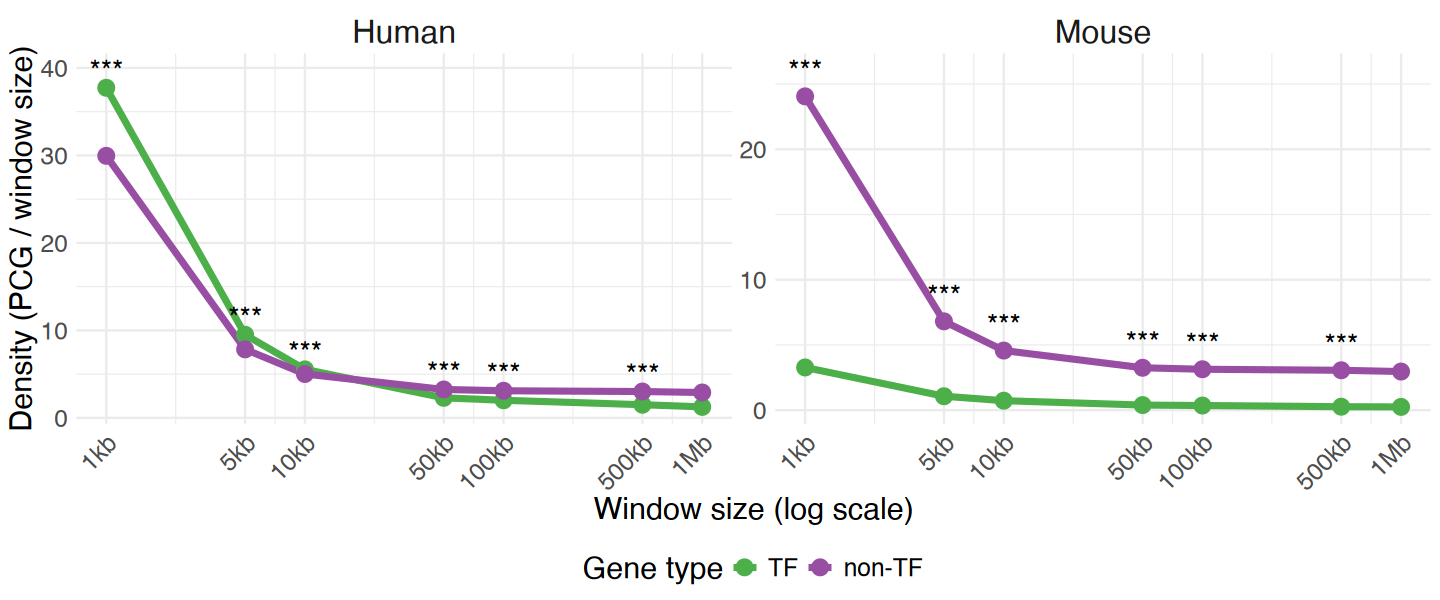

In [23]:
# Visualize TF vs non-TF comparison without strand information
options(repr.plot.width=12, repr.plot.height=5)



# Merge significance information with density data
density_combined_with_sig <- density_combined_df %>%
    left_join(pvalue_df %>% select(species, window_size, significance), 
              by = c("species", "window_size"))

# Calculate y position for significance labels (above the higher point)
density_max_per_window <- density_combined_with_sig %>%
    group_by(species, window_size) %>%
    summarise(
        max_density = max(combined_density),
        significance = first(significance[significance != ""]),
        .groups = 'drop'
    ) %>%
    filter(!is.na(significance) & significance != "")

p_density_combined <- density_combined_df %>%
    ggplot(aes(x = window_size / 1000, y = combined_density, color = gene_type, group = gene_type)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    # Add significance labels
    geom_text(data = density_max_per_window,
              aes(x = window_size / 1000, y = max_density + 2, label = significance),
              inherit.aes = FALSE, size = 6, color = "black") +
    facet_wrap(~str_to_title(species), scales = "free_y", ncol = 2) +
    scale_color_manual(values = c("TF" = green, "non-TF" = purple)) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Density (PCG / window size)",
         color = "Gene type") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

p_density_combined

In [24]:
# Save the main figure
ggsave(filename = file.path(out_dir, paste0("Fig_3_lncRNA_TF_vs_nonTF_density_", date, ".pdf")),
    plot = p_density_combined, 
    width = width * 0.6, height = 5.0, units = "in", dpi = dpi)

### Supplementary Figures

#### Supplementary Figure A: Normalized density comparison

#### Supplementary Figure B: Density by strand

In [25]:
# Create normalized version to compare distribution patterns
# Apply min-max normalization within each species and gene type
density_normalized_df <- density_combined_df %>%
    group_by(species, gene_type) %>%
    mutate(
        normalized_density = (combined_density - min(combined_density)) / (max(combined_density) - min(combined_density))
    ) %>%
    ungroup()

head(density_normalized_df)

species,window_size,gene_type,total_count,combined_density,normalized_density
<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>
human,1000,TF,37728,37.7280,1.0000000
human,1000,non-TF,29952,29.9520,1.0000000
human,5000,TF,47508,9.5016,0.2260991
human,5000,non-TF,39170,7.8340,0.1823727
human,10000,TF,55454,5.5454,0.1176295
human,10000,non-TF,50125,5.0125,0.0780714


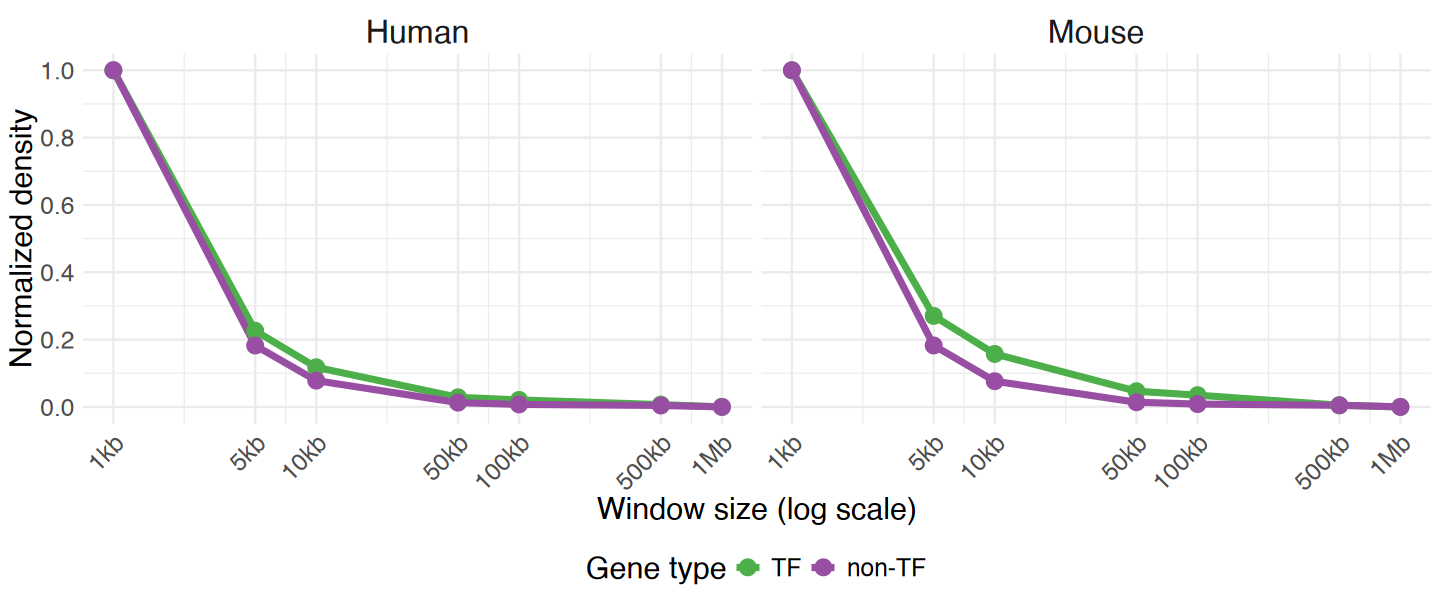

In [26]:
# Visualize normalized density comparison
options(repr.plot.width=12, repr.plot.height=5)

p_density_normalized <- density_normalized_df %>%
    ggplot(aes(x = window_size / 1000, y = normalized_density, color = gene_type, group = gene_type)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    facet_wrap(~str_to_title(species), ncol = 2) +
    scale_color_manual(values = c("TF" = green, "non-TF" = purple)) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Normalized density",
         color = "Gene type") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

p_density_normalized

In [27]:
# Save the normalized density supplementary figure
ggsave(filename = file.path(out_dir, paste0("Sup_Fig_lncRNA_TF_vs_nonTF_normalized_density_", date, ".pdf")),
    plot = p_density_normalized, 
    width = width * 0.6, height = 5.0, units = "in", dpi = dpi)

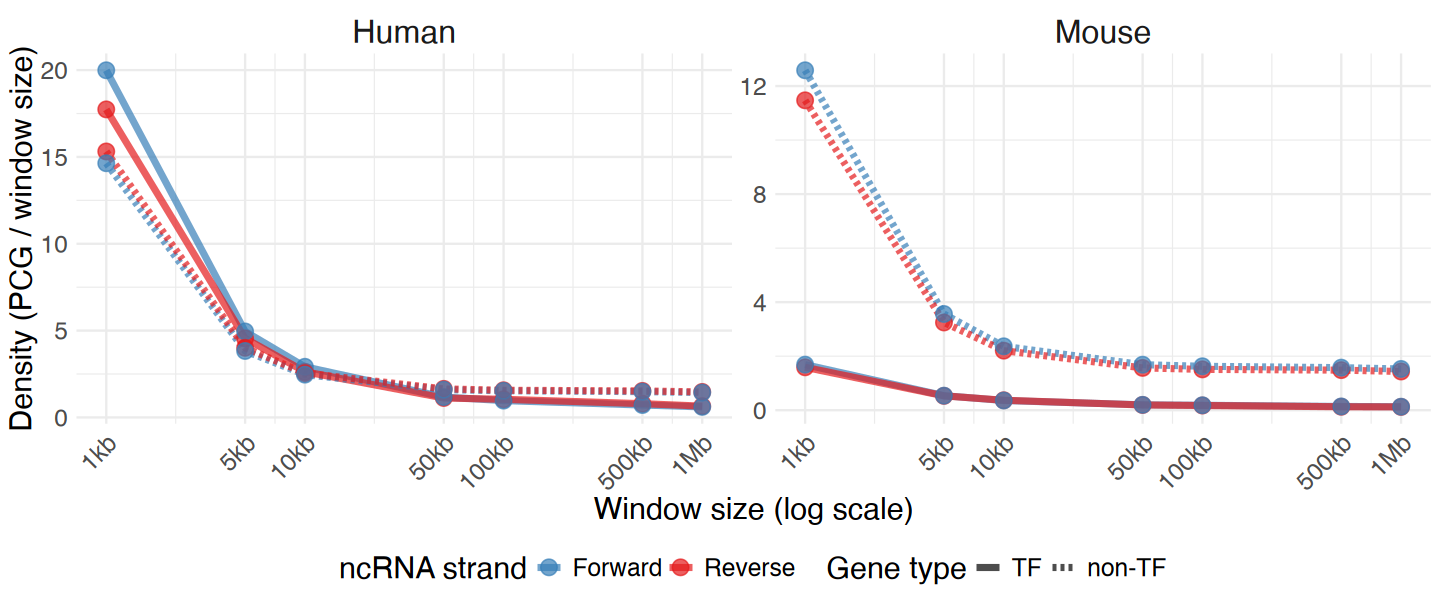

In [30]:
# Visualize density comparison between TF and non-TF genes with strand information
options(repr.plot.width=12, repr.plot.height=5)

p_density_by_strand <- density_df %>%
    ggplot(aes(x = window_size / 1000, y = density, color = strand, linetype = gene_type, group = interaction(strand, gene_type))) +
    geom_line(linewidth = line_size, alpha = 0.7) +
    geom_point(size = dot_size, alpha = 0.7) +
    facet_wrap(~str_to_title(species), scales = "free_y", ncol = 3) +
    scale_color_manual(values = c("Forward" = blue, "Reverse" = red)) +
    scale_linetype_manual(values = c("TF" = "solid", "non-TF" = "dashed")) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Density (PCG / window size)",
         color = "ncRNA strand",
         linetype = "Gene type") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

p_density_by_strand

In [31]:
# Save the strand-specific density supplementary figure
ggsave(filename = file.path(out_dir, paste0("Sup_Fig_lncRNA_TF_vs_nonTF_density_by_strand_", date, ".pdf")),
    plot = p_density_by_strand, 
    width = width * 0.6, height = 5.0, units = "in", dpi = dpi)